In [ ]:
'''1. Unsupervised Learning
Learning from data without labels; model finds hidden patterns or groups.

2. K-Means Working
Choose K clusters
Assign points to nearest centroid
Update centroids
Repeat until stable

3. Dendrogram
A tree diagram showing how clusters merge step-by-step in hierarchical clustering.

4. K-Means vs Hierarchical
K-Means	Hierarchical
Needs K value	No need initially
Fast	Slow
Flat clusters	Tree structure

5. DBSCAN Advantages
Detects noise/outliers
Works for irregular shapes
No need to specify K

6. Silhouette Score Use
Used to evaluate cluster quality (how well points fit in clusters).

7. Limitations of Hierarchical
Slow for large data
Cannot undo merges
Memory heavy

8. Feature Scaling Importance
Ensures all features contribute equally (distance-based algorithms depend on it).

9. DBSCAN Noise Detection
Points with few neighbors (below min_samples) are marked as noise.

10. Inertia (K-Means)
Sum of squared distances of points to their cluster center.

11. Elbow Method
Plot inertia vs K → choose K where curve bends ("elbow point").

12. Density in DBSCAN
Number of points within a given radius (eps).

13. Hierarchical on Categorical Data
Yes, using appropriate distance measures (e.g., Hamming distance).

14. Negative Silhouette Score
Point is closer to wrong cluster → poor clustering.

15. Linkage Criteria
Rule to measure distance between clusters (single, complete, average).

16. K-Means Poor Performance
Fails when:
Clusters have different sizes
Non-spherical shapes
Different densities

17. DBSCAN Parameters
eps → radius
min_samples → minimum points
They control cluster formation.

18. K-Means++
Improves centroid initialization → better and faster convergence.

19. Agglomerative Clustering
Bottom-up approach: start with points → merge clusters.

20. Silhouette vs Inertia
Silhouette considers both cohesion + separation, inertia only compactness.'''

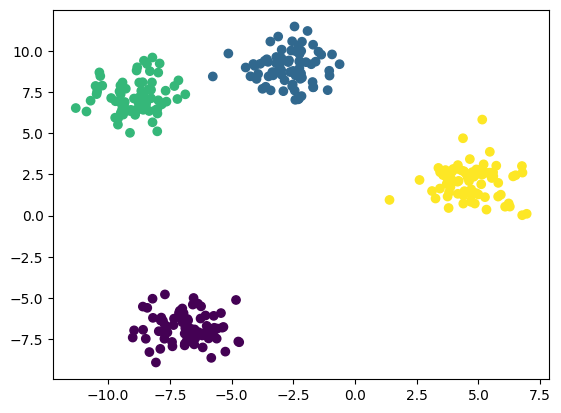

In [1]:
#21. K-Means with blobs
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

kmeans = KMeans(n_clusters=4)
y = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [2]:
#22. Iris + Agglomerative
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

X = load_iris().data
model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X)

print(labels[:10])

[1 1 1 1 1 1 1 1 1 1]


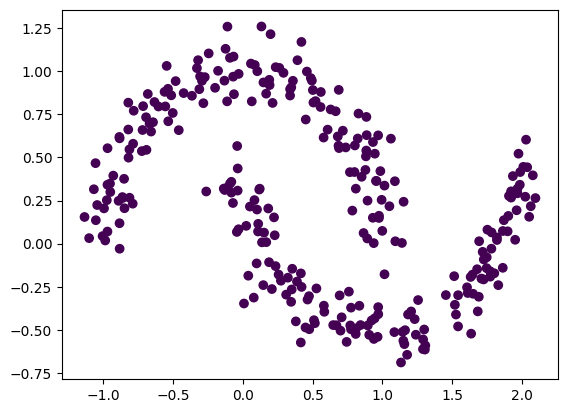

In [3]:
#23. Moons + DBSCAN
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.1)

db = DBSCAN(eps=0.3)
labels = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [4]:
#24. Wine + KMeans
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = load_wine().data
X = StandardScaler().fit_transform(X)

k = KMeans(n_clusters=3)
labels = k.fit_predict(X)

import numpy as np
print(np.bincount(labels))

[51 62 65]


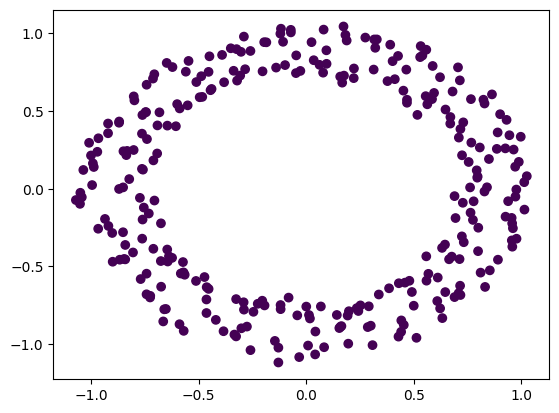

In [5]:
#25. Circles + DBSCAN
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, noise=0.05)

labels = DBSCAN(eps=0.2).fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [6]:
#26. Breast Cancer + KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

X = load_breast_cancer().data
X = MinMaxScaler().fit_transform(X)

k = KMeans(n_clusters=2)
k.fit(X)

print(k.cluster_centers_)

[[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


In [8]:
#27. Blobs + DBSCAN
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, _ = make_blobs(n_samples=300, cluster_std=[1.0,2.5,0.5])

labels = DBSCAN(eps=0.5).fit_predict(X)

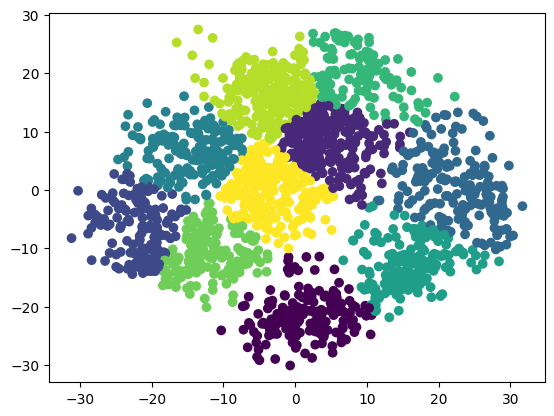

In [9]:
#28. Digits + PCA + KMeans
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = load_digits().data
X = PCA(n_components=2).fit_transform(X)

labels = KMeans(n_clusters=10).fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

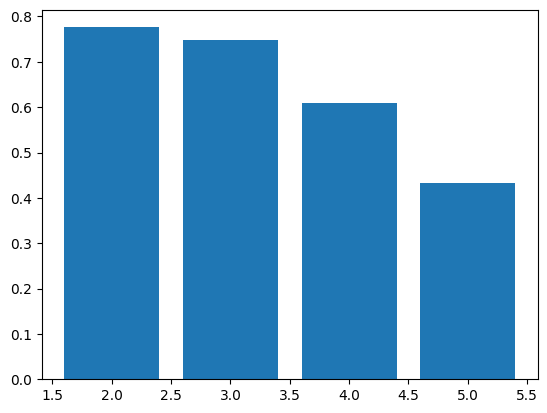

In [10]:
#29. Silhouette Scores
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300)

scores = []
k_range = range(2,6)

for k in k_range:
    labels = KMeans(n_clusters=k).fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.bar(k_range, scores)
plt.show()

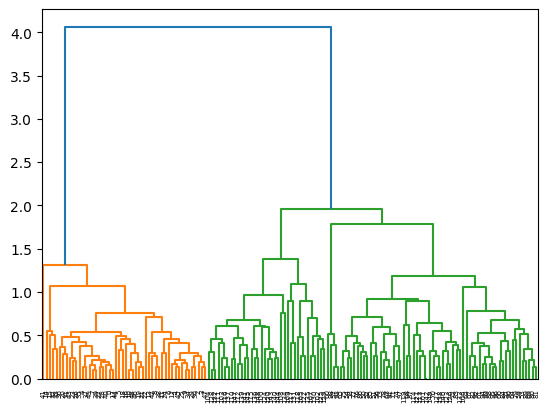

In [11]:
#30. Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

X = load_iris().data
Z = linkage(X, method='average')

dendrogram(Z)
plt.show()

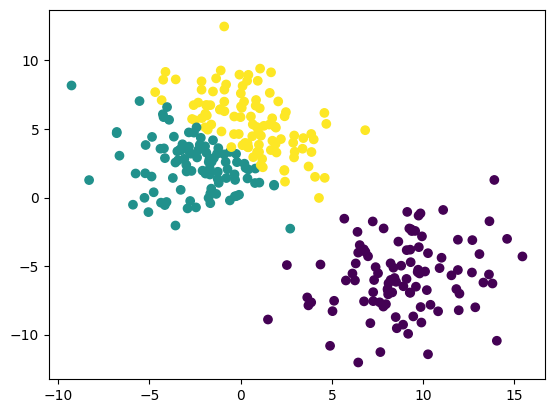

In [12]:
#31. Overlapping blobs + KMeans
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.5)

k = KMeans(n_clusters=3)
labels = k.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

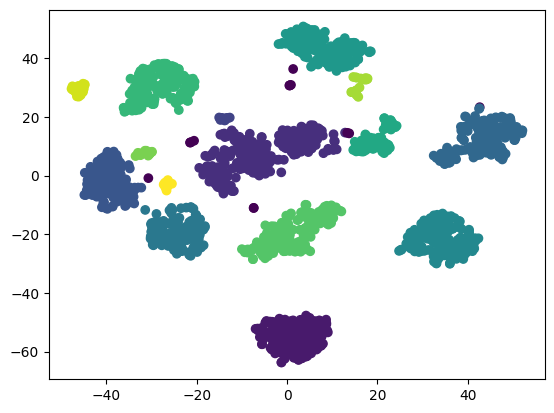

In [13]:
#32. Digits + t-SNE + DBSCAN
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X = load_digits().data
X = TSNE(n_components=2).fit_transform(X)

labels = DBSCAN(eps=3).fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

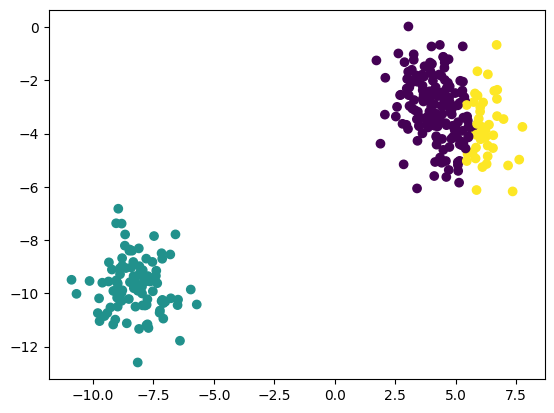

In [14]:
#33. Blobs + Agglomerative (complete)
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300)

model = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

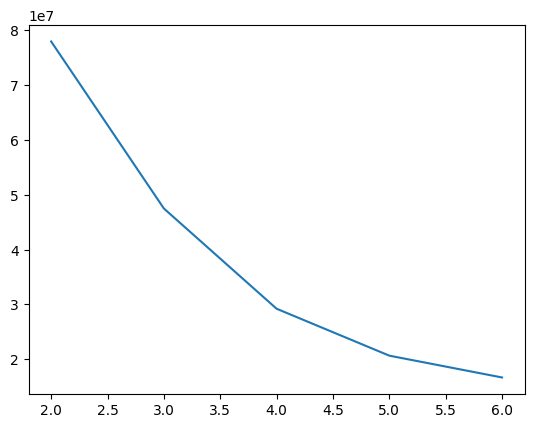

In [15]:
#34. Breast Cancer + Inertia Plot
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = load_breast_cancer().data

inertia = []
k_range = range(2,7)

for k in k_range:
    model = KMeans(n_clusters=k)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia)
plt.show()

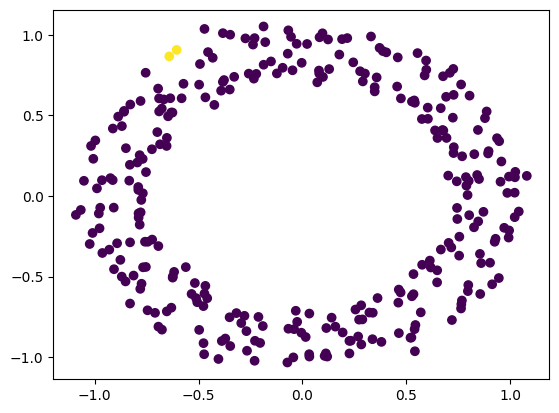

In [16]:
#35. Circles + Agglomerative
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, noise=0.05)

model = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [17]:
#36. Wine + DBSCAN (count clusters)
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

X = load_wine().data
X = StandardScaler().fit_transform(X)

labels = DBSCAN(eps=0.5).fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Clusters:", clusters)

Clusters: 0


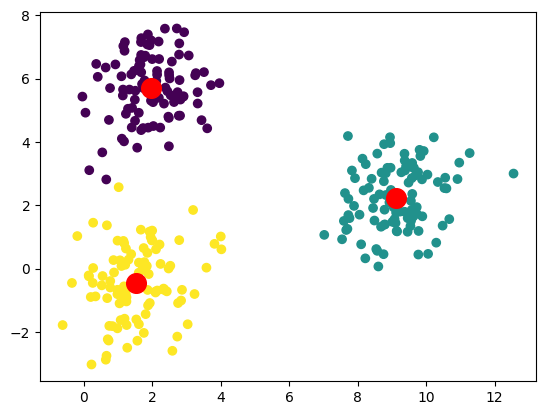

In [18]:
#37. Blobs + KMeans + Centers
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300)

k = KMeans(n_clusters=3)
labels = k.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(k.cluster_centers_[:,0], k.cluster_centers_[:,1], c='red', s=200)
plt.show()

In [19]:
#38. Iris + DBSCAN (noise count)
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
import numpy as np

X = load_iris().data

labels = DBSCAN(eps=0.5).fit_predict(X)

noise = np.sum(labels == -1)
print("Noise points:", noise)

Noise points: 17


In [20]:
#38. Iris + DBSCAN (noise count)
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN
import numpy as np

X = load_iris().data

labels = DBSCAN(eps=0.5).fit_predict(X)

noise = np.sum(labels == -1)
print("Noise points:", noise)

Noise points: 17


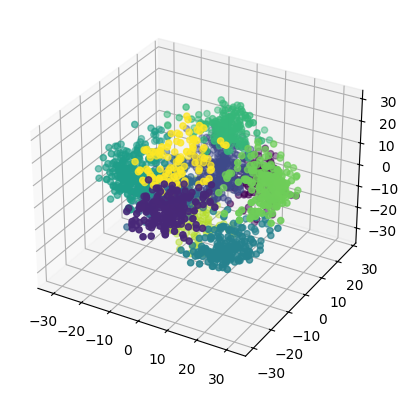

In [21]:
#40. Digits + PCA (3D) + KMeans
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = load_digits().data
X = PCA(n_components=3).fit_transform(X)

labels = KMeans(n_clusters=10).fit_predict(X)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=labels)
plt.show()

In [22]:
#41. Blobs + Silhouette Score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=300, centers=5)

labels = KMeans(n_clusters=5).fit_predict(X)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.6606178825540349


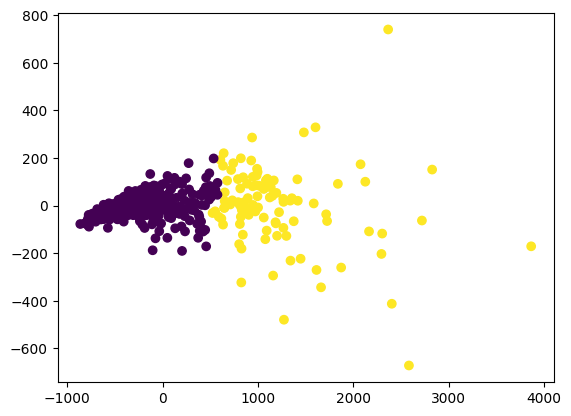

In [23]:
#42. Breast Cancer + PCA + Agglomerative
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X = load_breast_cancer().data
X = PCA(n_components=2).fit_transform(X)

labels = AgglomerativeClustering(n_clusters=2).fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

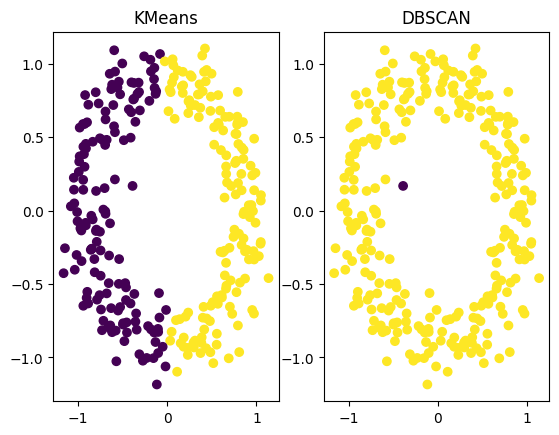

In [24]:
#43. Circles + KMeans vs DBSCAN
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=300, noise=0.1)

k_labels = KMeans(n_clusters=2).fit_predict(X)
d_labels = DBSCAN(eps=0.2).fit_predict(X)

plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=k_labels)
plt.title("KMeans")

plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=d_labels)
plt.title("DBSCAN")

plt.show()

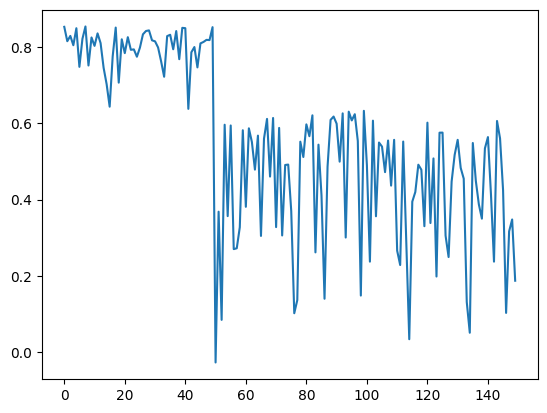

In [25]:
#44. Iris + Silhouette per sample
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

X = load_iris().data

labels = KMeans(n_clusters=3).fit_predict(X)

scores = silhouette_samples(X, labels)

plt.plot(scores)
plt.show()

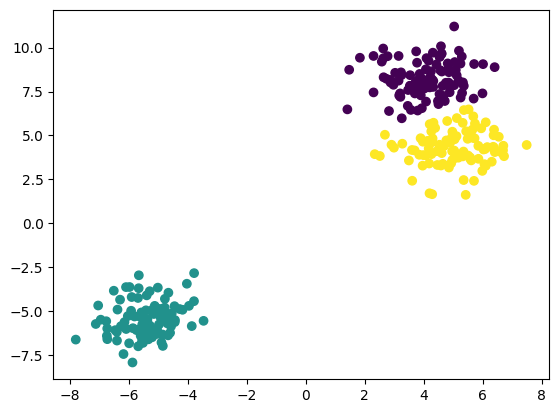

In [26]:
#45. Blobs + Agglomerative (average)
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300)

labels = AgglomerativeClustering(n_clusters=3, linkage='average').fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

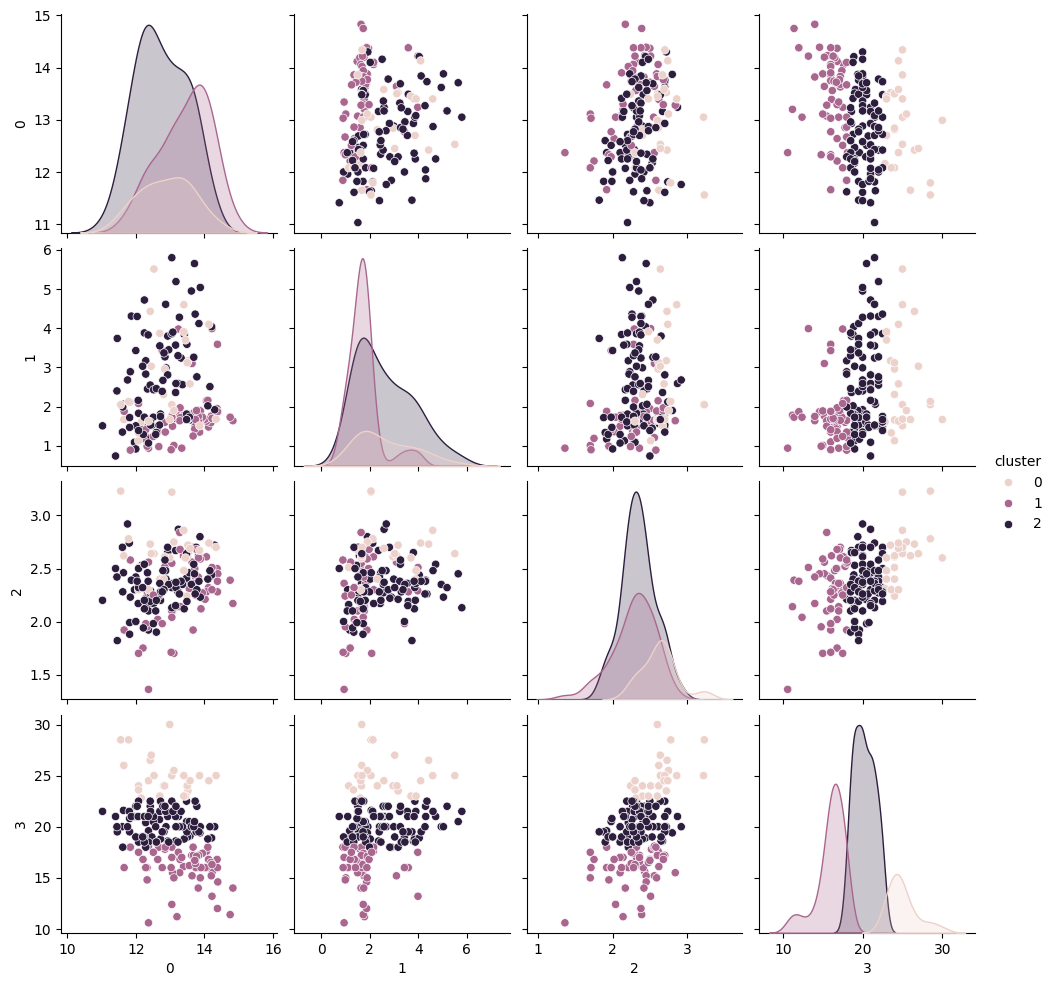

In [27]:
#46. Wine + KMeans + Pairplot
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
import pandas as pd

data = load_wine()
df = pd.DataFrame(data.data[:, :4])

df['cluster'] = KMeans(n_clusters=3).fit_predict(df)

sns.pairplot(df, hue='cluster')

In [28]:
#47. Noisy blobs + DBSCAN count
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

X, _ = make_blobs(n_samples=300, cluster_std=2)

labels = DBSCAN(eps=0.7).fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = np.sum(labels == -1)

print("Clusters:", clusters)
print("Noise:", noise)

Clusters: 3
Noise: 91


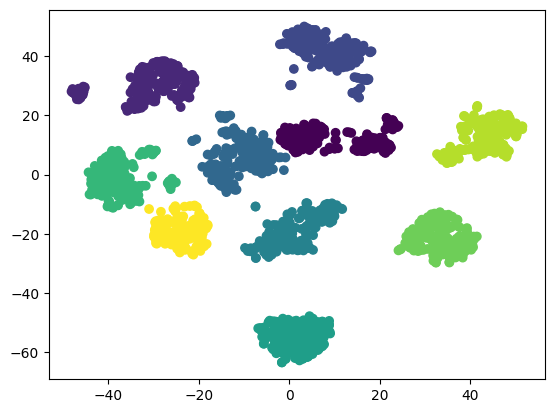

In [29]:
#48. Digits + t-SNE + Agglomerative
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X = load_digits().data
X = TSNE(n_components=2).fit_transform(X)

labels = AgglomerativeClustering(n_clusters=10).fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()